<a href="https://colab.research.google.com/github/dibendupal69724-ux/CV-documents/blob/main/Credit_Risk_Analysis_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A bank or other financial organization takes a calculated risk each time it grants a loan. In order to avoid financial losses, it is crucial to ascertain whether a borrower is going to fail or not. In this project, we apply supervised machine learning models that uses applicant data to forecast credit risk whether the applicant is safe or risky.
Here we used a Kaggle dataset for our project which can be found here https://www.kaggle.com/datasets/laotse/credit-risk-dataset/data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/credit_risk_dataset.csv.zip')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# Meaning of some of the columns


Loan_grade: The loan grade assigned by the lending institution, which typically reflects the risk level of the loan (A-G, with A being the lowest risk).

Loan_status: The target variable, indicating whether the loan was defaulted (1) or not (0).

Loan_percent_income: The loan amount as a percentage of the applicant's annual income.

Cb_person_default_on_file: Indicates if the person had a default in their credit history (Y for yes, N for no).

Cb_person_cred_hist_length: The length of the person's credit history in years.

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


# Finding and filling Missing Values


In [4]:
print(df.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


Replacing the missing values with median

In [5]:
median_emp_length = df['person_emp_length'].median()
median_int_rate = df['loan_int_rate'].median()

df['person_emp_length'] = df['person_emp_length'].fillna(median_emp_length)
df['loan_int_rate'] = df['loan_int_rate'].fillna(median_int_rate)

print("Missing values after replacement with median:")
print(df.isnull().sum())

Missing values after replacement with median:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [6]:
print('Person Employment Length')
print(f'Min : {df["person_emp_length"].min()}')
print(f'Max : {df["person_emp_length"].max()}')
print(f'Mean : {df["person_emp_length"].mean()}')
print(f'Median : {df["person_emp_length"].median()}')
print(f'Standard deviation : {df["person_emp_length"].std()}')
print(f'Inter Quantile range : {df["person_emp_length"].quantile(0.75)-df["person_emp_length"].quantile(0.25)}')
print(f'Emp_Length over 50 : {(df["person_emp_length"]>50).sum()}')

Person Employment Length
Min : 0.0
Max : 123.0
Mean : 4.767993615911114
Median : 4.0
Standard deviation : 4.087371678206524
Inter Quantile range : 5.0
Emp_Length over 50 : 2


In [7]:
df_clean1 = df[df['person_emp_length'] <= 50].copy()

In [8]:
df_clean1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32579 entries, 1 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32579 non-null  int64  
 1   person_income               32579 non-null  int64  
 2   person_home_ownership       32579 non-null  object 
 3   person_emp_length           32579 non-null  float64
 4   loan_intent                 32579 non-null  object 
 5   loan_grade                  32579 non-null  object 
 6   loan_amnt                   32579 non-null  int64  
 7   loan_int_rate               32579 non-null  float64
 8   loan_status                 32579 non-null  int64  
 9   loan_percent_income         32579 non-null  float64
 10  cb_person_default_on_file   32579 non-null  object 
 11  cb_person_cred_hist_length  32579 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.2+ MB


Finding the number of duplicated rows and removing them

In [9]:
print(f'Duplicate rows: {df_clean1.duplicated().sum()}')

Duplicate rows: 165


In [10]:
df_clean2 = df_clean1.drop_duplicates()


In [11]:
print(f'Duplicate rows: {df_clean2.duplicated().sum()}')

Duplicate rows: 0


# Data Cleaning

In [12]:
print('Age Distribution ')
print(f'Min age: {df_clean2["person_age"].min()},  Max age: {df_clean2["person_age"].max()}')
print(f'Ages over 100: {(df_clean2["person_age"] > 100).sum()}')

Age Distribution 
Min age: 20,  Max age: 144
Ages over 100: 5


In [13]:
print('Income Distribution')
print(f'Min income: Rs.{df_clean2["person_income"].min()}')
print(f'Max income: Rs.{df_clean2["person_income"].max()}')
print(f'Mean income: Rs.{df_clean2["person_income"].mean()}')
print(f'Median income: Rs.{df_clean2["person_income"].median()}')
print(f'Incomes over Rs.10L: {(df_clean2["person_income"] > 1000000).sum()}')

Income Distribution
Min income: Rs.4000
Max income: Rs.6000000
Mean income: Rs.66087.97522675387
Median income: Rs.55000.0
Incomes over Rs.10L: 9


In [14]:
print('Employment Length Check')
print(f'Min: {df_clean2["person_emp_length"].min()}')
print(f'Max: {df_clean2["person_emp_length"].max()}')

# Check rows where employment length is greater than or equal to age which is impossible
check = (df_clean2['person_emp_length'] >= df_clean2['person_age']).sum()
print(f'Rows where emp_length >= age: {check}')

Employment Length Check
Min: 0.0
Max: 41.0
Rows where emp_length >= age: 0


In [15]:
df_cleaned = df_clean2[(df_clean2['person_age'] <= 100) & (df_clean2['person_income'] <= 1000000)].copy()

In [16]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32401 entries, 1 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32401 non-null  int64  
 1   person_income               32401 non-null  int64  
 2   person_home_ownership       32401 non-null  object 
 3   person_emp_length           32401 non-null  float64
 4   loan_intent                 32401 non-null  object 
 5   loan_grade                  32401 non-null  object 
 6   loan_amnt                   32401 non-null  int64  
 7   loan_int_rate               32401 non-null  float64
 8   loan_status                 32401 non-null  int64  
 9   loan_percent_income         32401 non-null  float64
 10  cb_person_default_on_file   32401 non-null  object 
 11  cb_person_cred_hist_length  32401 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.2+ MB


In [17]:
print('Target Feature: Loan Status ')
print(df_cleaned['loan_status'].value_counts())
print(f"Loan Status : Non Default=0,Default=1")

Target Feature: Loan Status 
loan_status
0    25313
1     7088
Name: count, dtype: int64
Loan Status : Non Default=0,Default=1


# Graphs and Plots

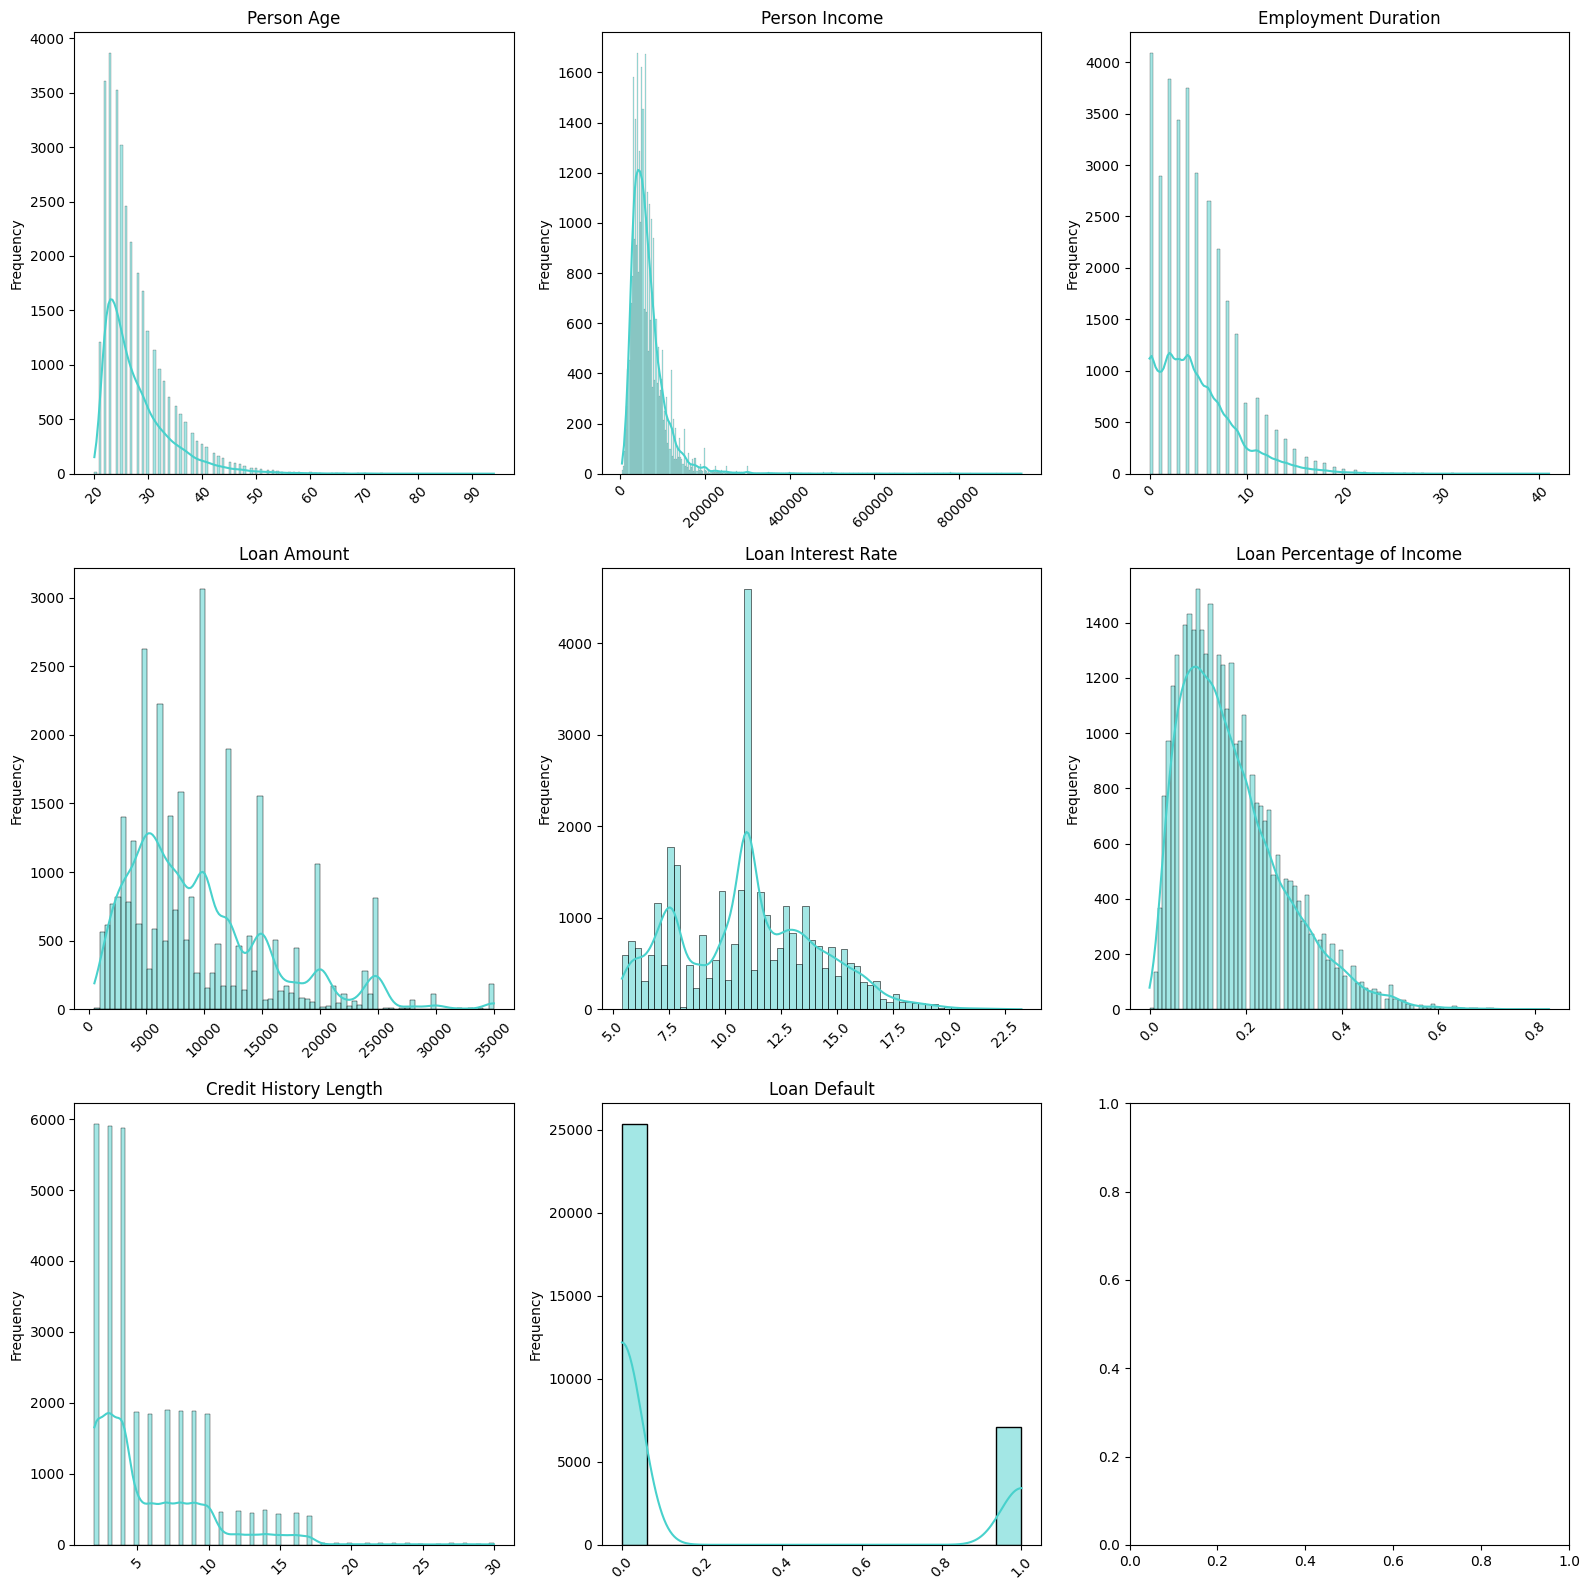

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = ["person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "loan_status"]

titles = {
    "person_age": "Person Age",
    "person_income": "Person Income",
    "person_emp_length": "Employment Duration",
    "loan_amnt": "Loan Amount",
    "loan_int_rate": "Loan Interest Rate","loan_percent_income": "Loan Percentage of Income",
    "cb_person_cred_hist_length": "Credit History Length","loan_status":"Loan Default"}


fig, axes = plt.subplots(3,3, figsize=(16,16))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numerical_columns):
    sns.histplot(x=col, data=df_cleaned, ax=axes[i], kde=True, color='mediumturquoise')
    axes[i].set_title(titles[col])
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Frequency')
    axes[i].set_xlabel('') # Clear x-axis label as title already mentions the column


plt.tight_layout()
plt.show()

# OBSERVATIONS

Person Age: The distribution of Person Age appears to be somewhat right-skewed, with a concentration of individuals in their 20s and 30s. There are fewer individuals in older age groups, and as we previously cleaned, ages over 100 have been removed.

Person Income: This distribution is heavily right-skewed, which is typical for income data. Most individuals have lower incomes, with a long tail extending to higher income levels, though values over 1,000,000 were filtered out.

Person Employment Duration:It shows a distribution concentrated at lower employment lengths, likely indicating many people with 0-5 years of experience. There's a decreasing frequency as employment length increases, with very few individuals having long employment histories (over 20-30 years).

Loan_amnt: The loan_amnt distribution shows that smaller loan amounts are more common, with the frequency decreasing as the loan amount increases. There might be a few peaks indicating popular loan amounts.

Loan Interest Rate: This distribution appears to be multimodal or somewhat spread out, indicating several common interest rate ranges. There isn't a single strong peak, suggesting a variety of rates are applied.

Loan Percent Income: This column shows the loan amount as a percentage of income. The distribution is skewed towards lower percentages, meaning most loans represent a relatively small portion of the applicant's income. There's a tail extending to higher percentages.

Credit History Length : The Credit History Length is also right-skewed, with most applicants having shorter credit histories (e.g., under 10 years). As expected, fewer people have very long credit histories.

Loan Default: This is a categorical variable (0 for not defaulted, 1 for defaulted). The histogram clearly shows a significant class imbalance, with a much larger number of loans having a loan_status of 0 (not defaulted) compared to 1 (defaulted). This imbalance will be important to consider for model training.

# Data Spread

Boxplots provide the view of the numerical datas by showcasing the spread of the data helping to identify potential outliers.

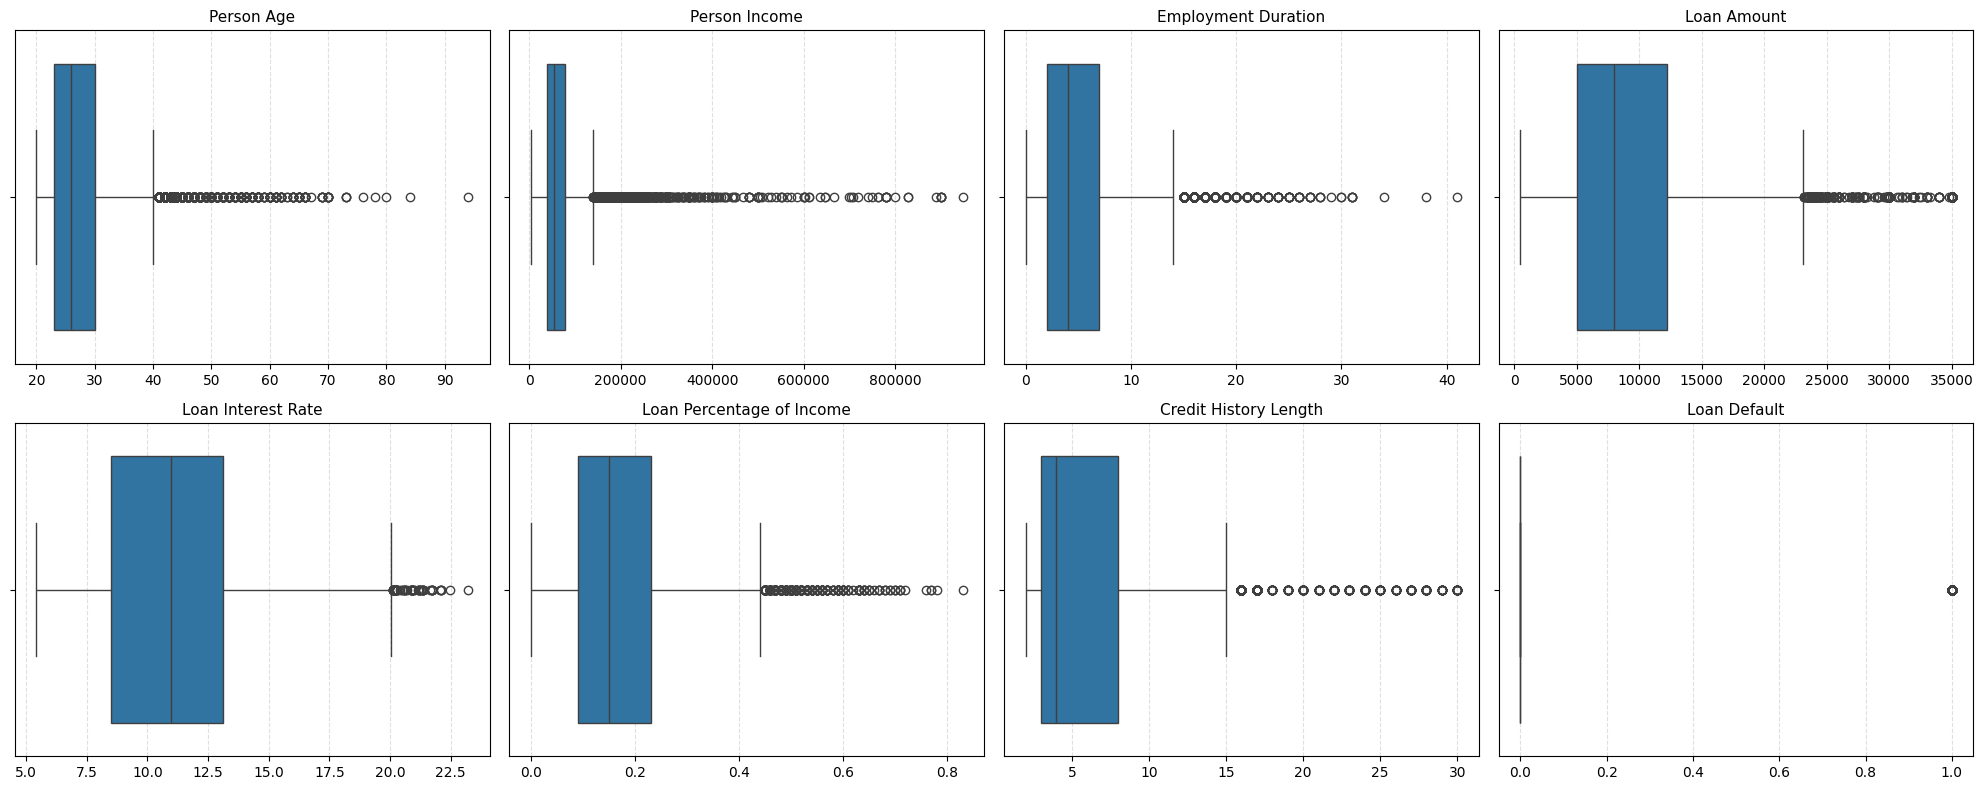

In [19]:
numerical_columns2 = ["person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"]
titles2 = {
    "person_age": "Person Age",
    "person_income": "Person Income",
    "person_emp_length": "Employment Duration",
    "loan_amnt": "Loan Amount",
    "loan_int_rate": "Loan Interest Rate","loan_percent_income": "Loan Percentage of Income",
    "cb_person_cred_hist_length": "Credit History Length"}

num_columns = len(numerical_columns)
num_rows = 2
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20,8))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.boxplot(x=col, data=df_cleaned, ax=axes[i])
    axes[i].set_title(titles[col], fontsize=11)
    axes[i].set_xlabel("")
    axes[i].grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Boxplot Observations

- **Person Age**: This boxplot  shows a relatively compact interquartile range (IQR), indicating that most of the population falls within a certain age bracket. There are several outliers on the upper end, which are individuals significantly older than the majority. The median age appears to be around the mid-20s to early 30s.

- **Person Income**: This boxplot displays a very long upper whisker and numerous outliers, suggesting a highly right-skewed distribution. The majority of incomes are concentrated at the lower end, with a small number of individuals having significantly higher incomes. The median income is relatively low compared to the maximum values observed.

- **Person Employment Length**:This boxplot indicates a distribution with a median employment length of a few years. There are a considerable number of outliers on the higher side, representing individuals with very long employment histories. The bulk of the data is concentrated at shorter employment durations.

- **Loan Amount**: This boxplot shows a spread that indicates most loan amounts are relatively small. However, there are many outliers at higher loan amounts, signifying that while large loans are less frequent, they do occur. The median loan amount is likely in the lower to middle range of the observed values.

- **Loan Interest Rate**: This boxplot shows a distribution with a central tendency around the median, but also a noticeable spread and a number of outliers on both the lower and higher ends. This suggests a variety of interest rates are applied, and some loans have exceptionally high or low rates.

- **Loan Percentage of Income**: This boxplot reveals that most loans constitute a small percentage of the applicant's income. There are many outliers extending to much higher percentages, indicating cases where the loan amount is a substantial portion of the income, which could signify higher risk.

- **Credit History Length**: This boxplot shows a right-skewed distribution, with most individuals having shorter credit histories (e.g., under 10 years). There are outliers representing individuals with very long credit histories.

# Heatmap

In [20]:
correlation_matrix = df_cleaned[numerical_columns].corr()
renamed_correlation_matrix = correlation_matrix.rename(columns=titles, index=titles)
display(renamed_correlation_matrix)

,Person Age,Person Income,Employment Duration,Loan Amount,Loan Interest Rate,Loan Percentage of Income,Credit History Length,Loan Default
Person Age,1.000000,0.133396,0.170406,0.051940,0.010576,-0.040436,0.877976,-0.021430
Person Income,0.133396,1.000000,0.170196,0.355355,0.001106,-0.317285,0.115285,-0.184905
Employment Duration,0.170406,0.170196,1.000000,0.111932,-0.052961,-0.058288,0.147675,-0.085936
Loan Amount,0.051940,0.355355,0.111932,1.000000,0.139580,0.572744,0.042341,0.105583
Loan Interest Rate,0.010576,0.001106,-0.052961,0.139580,1.000000,0.114202,0.015007,0.320032
Loan Percentage of Income,-0.040436,-0.317285,-0.058288,0.572744,0.114202,1.000000,-0.030239,0.379503
Credit History Length,0.877976,0.115285,0.147675,0.042341,0.015007,-0.030239,1.000000,-0.016112
Loan Default,-0.021430,-0.184905,-0.085936,0.105583,0.320032,0.379503,-0.016112,1.000000


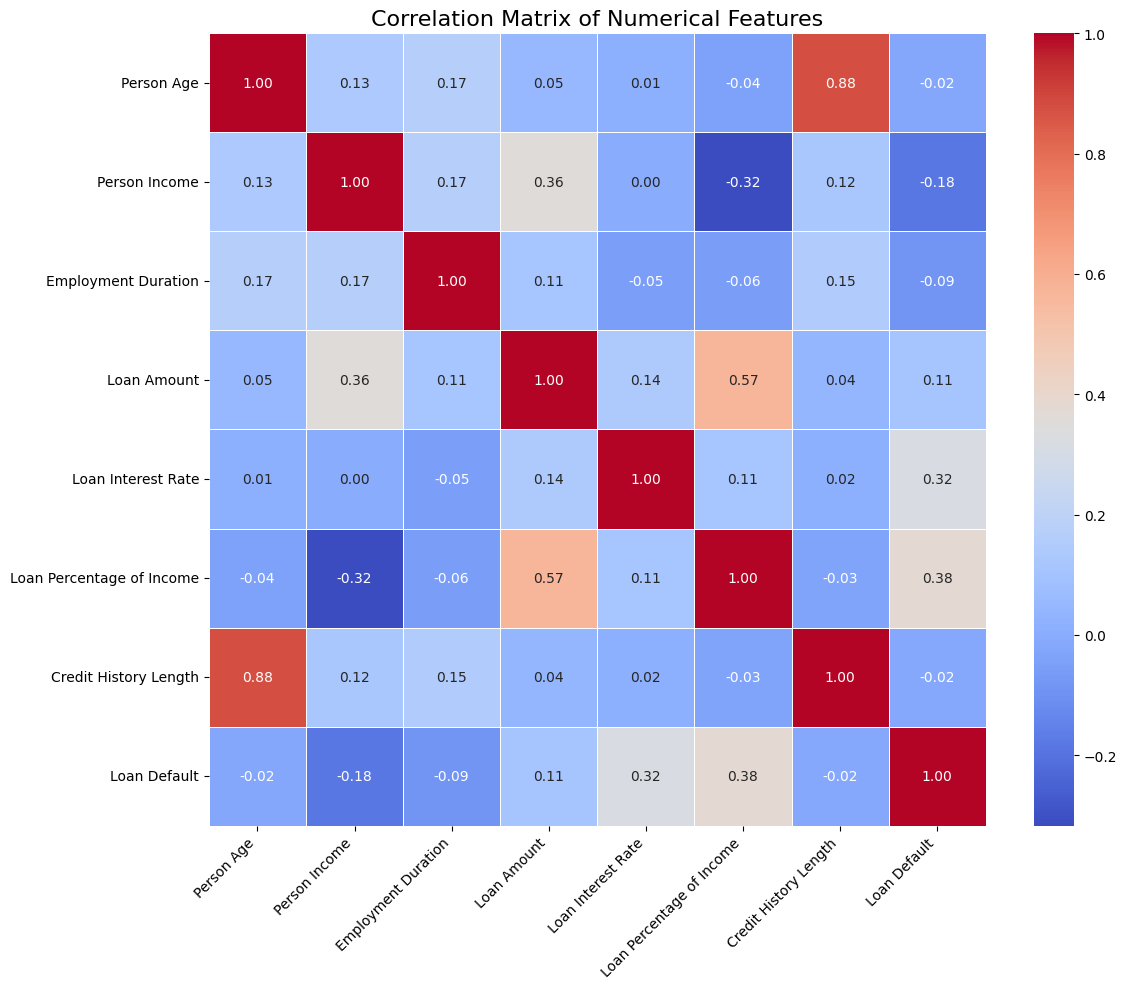

In [21]:
plt.figure(figsize=(12, 10))
sns.heatmap(renamed_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Heatmap Analysis of Numerical Feature Correlations

By examining the heatmap, we can observe the following correlations between numerical features:

-   **Person Age and Credit History Length (0.88)**: There is a very strong positive correlation between a person's age and their credit history length. This is highly intuitive, as older individuals generally have had more time to build a longer credit history.

-   **Person Income and Loan Amount (0.36)**: There is a moderate positive correlation between a person's income and the loan amount they receive. This suggests that higher earners tend to take out larger loans, which is expected as lenders often consider income as a factor in loan approval and amount.

-   **Person Income and Loan Percentage of Income (-0.32)**: There is a weak negative correlation between Person Income and Loan Percentage of Income. This indicates that as income increases, the loan amount tends to represent a smaller *percentage* of that income. This could be due to higher earners having more financial flexibility, or simply that loan amounts don't scale proportionally with very high incomes.

-   **Loan Amount and Loan Percentage of Income (0.57)**: There is a strong positive correlation between the Loan Amount and Loan Percentage of Income. This is also expected, as a larger loan amount will naturally represent a larger percentage of a given income.

-   **Loan Interest Rate and Loan Default (0.32)**: A moderate positive correlation exists between Loan Interest Rate and Loan Default. This suggests that loans with higher interest rates are more likely to default (where Loan Default 1 indicates default). This is a critical finding, implying that higher interest rates might be a risk indicator or contribute to default.

-   **Employment Duration and Person Age (0.17)**: There's a weak positive correlation, which is reasonable as older individuals generally have longer employment histories.

-   **Employment Duration and Loan Default (-0.09)**: A very weak negative correlation, suggesting that individuals with longer employment histories might be slightly less likely to default, though the relationship is not strong.

-   **Loan Percentage of Income and Loan Default (0.37)**: There is a moderate positive correlation between the Loan Percentage of Income and Loan Default. This indicates that loans that constitute a larger percentage of an applicant's income are more likely to default. This is an important risk factor, as a high debt-to-income ratio can make repayment difficult.

-   **Person Age, Person Income, Employment Duration, Loan Amount, Credit History Length and Loan Default**: Most of these features show a very weak or negligible correlation with Loan Default, except for Loan Interest Rate and Loan Percentage of Income as noted above. This suggests that while these features might contribute to overall credit risk, their linear relationship with default status is not very strong on its own.

# Loan Default Rate across various categorical Groups

In this context, the 'default rate' refers to the proportion of loans that have defaulted within a specific group or category. It's calculated as the number of loans with loan_status = 1 (defaulted) divided by the total number of loans in that group. Essentially, it tells us how likely a loan is to default for a given characteristic.

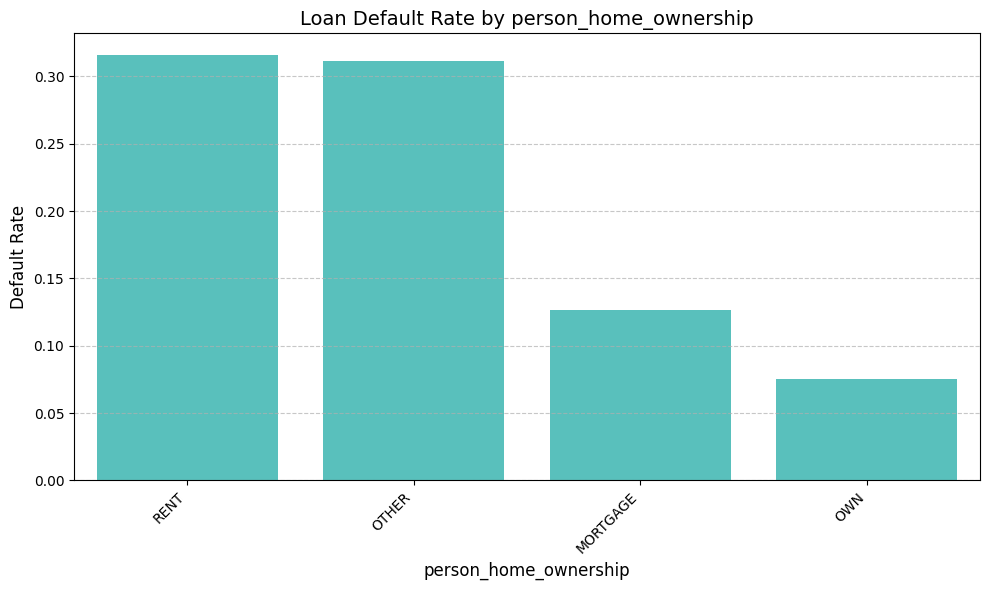

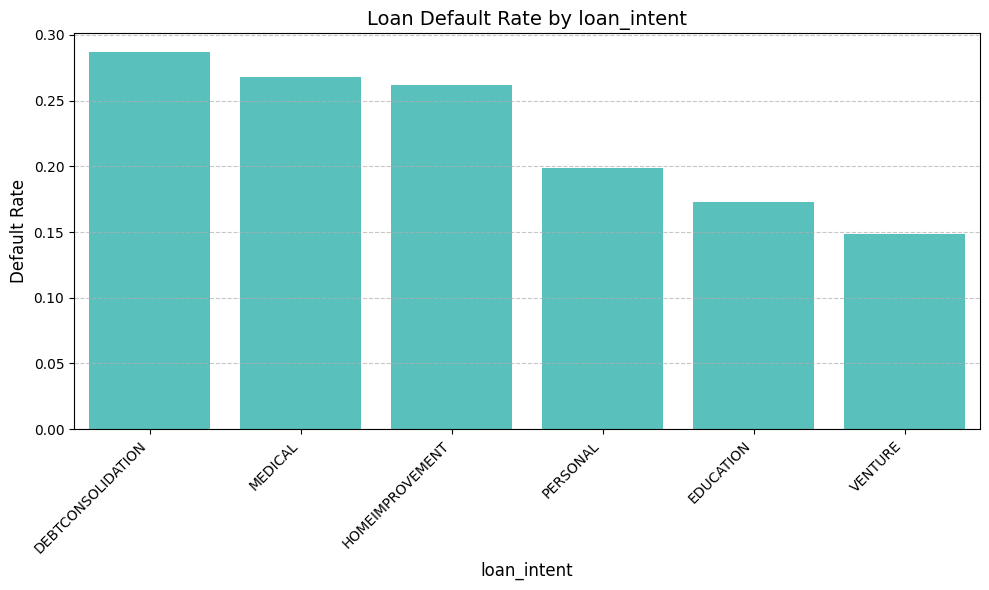

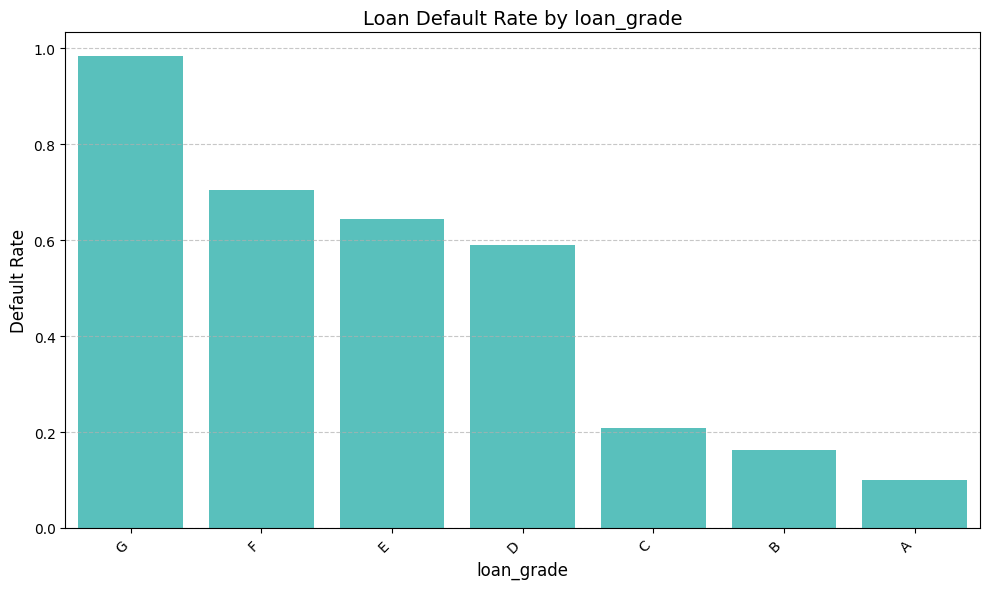

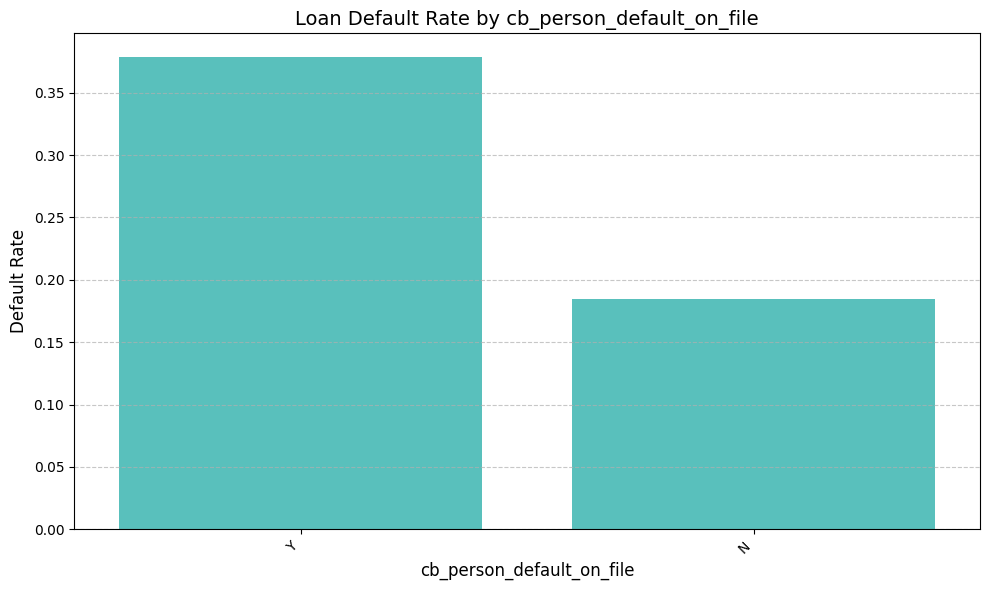

In [22]:
categorical_columns = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
 #default_rate1 = df_cleaned.groupby('person_home_ownership')['loan_status'].mean()
 #print(default_rate1)
for col in categorical_columns:
    plt.figure(figsize=(10, 6)) # Create a new figure for each plot

    default_rate = df_cleaned.groupby(col)['loan_status'].mean().sort_values(ascending=False).reset_index()
    sns.barplot(x=col, y='loan_status', data=default_rate, color='mediumturquoise')

    plt.title(f'Loan Default Rate by {titles[col] if col in titles else col}', fontsize=14)
    plt.xlabel(titles[col] if col in titles else col, fontsize=12)
    plt.ylabel('Default Rate', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

### Observations on Loan Default Rates Across Applicant Groups

-   **Person Home Ownership**: The default rate varies significantly by home ownership status. Renters might have a higher default rate compared to those who own their home or have a mortgage, possibly indicating different financial stability levels or risk profiles.

-   **Loan Intent**: Different loan intentions show varying default rates. Certain intentions, like medical or education loans, might have a higher or lower default propensity depending on the financial strain they represent or the borrower's future earning potential.

-   **Loan Grade**: As expected, lower loan grades (e.g., G, F, E) typically correspond to substantially higher default rates, confirming that the loan grading system is an effective indicator of credit risk. Higher grades (A, B) have much lower default rates.

-   **Default on File**: Applicants with a prior default on file (indicated by 'Y') have a considerably higher default rate than those without ('N'). This feature is a strong predictor of future default behavior.

# Encoding Categorical Columns

In [23]:
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_columns, drop_first=True)

#Without drop_first=True: Each unique category in a categorical column would get its own new column. For example, if 'person_home_ownership' had 4 unique values, it would create 4 new columns.
#With drop_first=True: This argument prevents multicollinearity and reduces redundancy. For each categorical feature, it creates N-1 new columns, where N is the number of unique categories. One category for each feature is dropped (hence 'drop_first') because its information can be inferred from the other N-1 columns.

# Converting boolean columns to integers (True becomes 1, False becomes 0)
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)
df_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,21,9600,5.0,1000,11.14,0,0.10,2,0,1,...,0,0,0,1,0,0,0,0,0,0
2,25,9600,1.0,5500,12.87,1,0.57,3,0,0,...,1,0,0,0,1,0,0,0,0,0
3,23,65500,4.0,35000,15.23,1,0.53,2,0,0,...,1,0,0,0,1,0,0,0,0,0
4,24,54400,8.0,35000,14.27,1,0.55,4,0,0,...,1,0,0,0,1,0,0,0,0,1
5,21,9900,2.0,2500,7.14,1,0.25,2,0,1,...,0,0,1,0,0,0,0,0,0,0


# Scaling and Feature Selection

Based on our earlier correlation analysis, there's a very strong positive correlation (0.88) between 'Person Age' and 'Credit History Length'. This high correlation can lead to multicollinearity issues in our machine learning model, making it harder to interpret the individual impact of these features

While both are related, 'Credit History Length' is a more direct and specific indicator of an individual's credit behavior and experience relevant to loan risk than person age.

Hence we drop the 'person_age' column.

In [24]:
df_encoded = df_encoded.drop(columns=['person_age'])
display(df_encoded.head())

,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,9600,5.0,1000,11.14,0,0.10,2,0,1,0,...,0,0,0,1,0,0,0,0,0,0
2,9600,1.0,5500,12.87,1,0.57,3,0,0,0,...,1,0,0,0,1,0,0,0,0,0
3,65500,4.0,35000,15.23,1,0.53,2,0,0,1,...,1,0,0,0,1,0,0,0,0,0
4,54400,8.0,35000,14.27,1,0.55,4,0,0,1,...,1,0,0,0,1,0,0,0,0,1
5,9900,2.0,2500,7.14,1,0.25,2,0,1,0,...,0,0,1,0,0,0,0,0,0,0


In [27]:
from sklearn.preprocessing import StandardScaler

scaling_columns = [
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"]


# Separate features to be scaled, other features, and the target variable
X_to_be_scaled = df_encoded[scaling_columns]
X_others = df_encoded.drop(columns=scaling_columns + ['loan_status'])
y = df_encoded['loan_status']

scaler = StandardScaler()

X_scaled_numerical = scaler.fit_transform(X_to_be_scaled)

# Convert scaled numerical features back to a DataFrame
X_scaled_numerical_df = pd.DataFrame(X_scaled_numerical, columns=scaling_columns, index=df_encoded.index)

# Concatenate scaled numerical features, other unscaled features, and the target variable
df_scaled = pd.concat([X_scaled_numerical_df, X_others, y], axis=1)

# Our X after Concantenation
X = pd.concat([X_scaled_numerical_df, X_others], axis=1)

display(df_scaled.head())

,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,...,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y,loan_status
1,-1.188679,0.060004,-1.359333,0.040598,-0.658352,-0.939542,0,1,0,1,...,0,0,1,0,0,0,0,0,0,0
2,-1.188679,-0.944227,-0.647457,0.601722,3.743844,-0.692847,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,-0.000773,-0.191054,4.019283,1.367187,3.369189,-0.939542,0,0,1,0,...,0,0,0,1,0,0,0,0,0,1
4,-0.236654,0.813177,4.019283,1.055812,3.556516,-0.446153,0,0,1,0,...,0,0,0,1,0,0,0,0,1,1
5,-1.182303,-0.693169,-1.122041,-1.256800,0.746604,-0.939542,0,1,0,0,...,0,1,0,0,0,0,0,0,0,1


In [28]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (25920, 21)
Shape of X_test: (6481, 21)
Shape of y_train: (25920,)
Shape of y_test: (6481,)


In [29]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


In [30]:
from sklearn.ensemble import GradientBoostingClassifier

#Gradient Boosting Classifier
gbc_model = GradientBoostingClassifier(random_state=42)

# Train the model
gbc_model.fit(X_train, y_train)

print("Gradient Boosting Classifier trained successfully!")

Gradient Boosting Classifier trained successfully!


In [31]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Set max_iter for convergence as the data is scaled
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [43]:
from sklearn.metrics import classification_report

# Random Forest Classifier Report
y_pred_rf = rf_model.predict(X_test)
text = "Random Forest Classifier Report"
print(f"{text:^70}")
print(classification_report(y_test, y_pred_rf))

                   Random Forest Classifier Report                    
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5083
           1       0.96      0.71      0.82      1398

    accuracy                           0.93      6481
   macro avg       0.94      0.85      0.89      6481
weighted avg       0.93      0.93      0.93      6481



In [44]:
# Gradient Boosting Classifier Report
y_pred_gbc = gbc_model.predict(X_test)
text = "Gradient Boosting Classifier Report"
print(f"{text:^70}")
print(classification_report(y_test, y_pred_gbc))

                 Gradient Boosting Classifier Report                  
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      5083
           1       0.92      0.69      0.79      1398

    accuracy                           0.92      6481
   macro avg       0.92      0.84      0.87      6481
weighted avg       0.92      0.92      0.92      6481



In [42]:
# Logistic Regression Model Report
y_pred_lr = lr_model.predict(X_test)
text=" Logistic Regression Model Report "
print(f"{text:^70}")
print(classification_report(y_test, y_pred_lr))

                   Logistic Regression Model Report                   
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5083
           1       0.76      0.57      0.65      1398

    accuracy                           0.87      6481
   macro avg       0.82      0.76      0.78      6481
weighted avg       0.86      0.87      0.86      6481



## Understanding the Classification Report

A classification report provides a comprehensive summary of a classification model's performance. It includes the following key metrics for each class (0 for non-default, 1 for default) and overall:

*   **Precision**: The ability of the classifier not to label as positive a sample that is negative. It is the ratio `tp / (tp + fp)`, where `tp` is the number of true positives and `fp` is the number of false positives. High precision means a low false positive rate.

*   **Recall (Sensitivity)**: The ability of the classifier to find all the positive samples. It is the ratio `tp / (tp + fn)`, where `tp` is the number of true positives and `fn` is the number of false negatives. High recall means a low false negative rate.

*   **F1-score**: The harmonic mean of precision and recall. It gives a more balanced measure of a model's performance, especially when there is an uneven class distribution. It is calculated as `2 * (precision * recall) / (precision + recall)`.

*   **Support**: The number of actual occurrences of the class in the specified dataset (in this case, `y_test`).

*   **Accuracy**: The proportion of correctly classified instances among the total instances. It is calculated as `(tp + tn) / (tp + tn + fp + fn)`.

*   **Macro Avg**: The average of the unweighted mean of precision, recall, and F1-score across all classes. This treats all classes equally.

*   **Weighted Avg**: The average of the precision, recall, and F1-score for each class, weighted by their `support`. This accounts for class imbalance.

## Analysis of Model Performance

Let's analyze the classification reports for each of our trained models:

### 1. Random Forest Classifier Report

```
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5083
           1       0.96      0.71      0.82      1398

    accuracy                           0.93      6481
   macro avg       0.94      0.85      0.89      6481
weighted avg       0.93      0.93      0.93      6481
```

**Observations:**
*   **Overall Accuracy:** 93%, which is quite good.
*   **Class 0 (Non-Default):** Excellent performance with very high precision (0.93), recall (0.99), and F1-score (0.96). This means it's very good at identifying non-defaulting loans and rarely misclassifies a non-default as a default.
*   **Class 1 (Default):** High precision (0.96) indicates that when the model predicts a default, it's usually correct. However, the recall (0.71) is lower, meaning it misses about 29% of actual defaults (false negatives). The F1-score (0.82) is respectable but lower than for class 0.
*   **Interpretation:** The Random Forest model is very effective at identifying non-defaulting loans and has a low rate of false positives for defaults. However, it's moderately less effective at identifying all actual defaulting loans, leading to a higher rate of false negatives for the default class.

### 2. Gradient Boosting Classifier Report

```
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      5083
           1       0.92      0.69      0.79      1398

    accuracy                           0.92      6481
   macro avg       0.92      0.84      0.87      6481
weighted avg       0.92      0.92      0.92      6481
```

**Observations:**
*   **Overall Accuracy:** 92%, slightly lower than Random Forest.
*   **Class 0 (Non-Default):** Strong performance with high precision (0.92), recall (0.98), and F1-score (0.95), similar to Random Forest.
*   **Class 1 (Default):** Good precision (0.92), but slightly lower recall (0.69) compared to Random Forest. This means it misses slightly more actual defaults (31% false negatives). The F1-score (0.79) is also slightly lower.
*   **Interpretation:** The Gradient Boosting model performs very similarly to Random Forest, with strong performance on non-default cases. It shows a slightly higher tendency to miss actual defaults compared to the Random Forest model.

### 3. Logistic Regression Model Report

```
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5083
           1       0.76      0.57      0.65      1398

    accuracy                           0.87      6481
   macro avg       0.82      0.76      0.78      6481
weighted avg       0.86      0.87      0.86      6481
```

**Observations:**
*   **Overall Accuracy:** 87%, the lowest among the three models.
*   **Class 0 (Non-Default):** Decent precision (0.89) and recall (0.95), leading to an F1-score of 0.92. This is still good, but noticeably lower than the tree-based models.
*   **Class 1 (Default):** Significantly lower precision (0.76) and recall (0.57), resulting in an F1-score of 0.65. This indicates that when it predicts a default, it's correct only 76% of the time, and it misses a large proportion (43%) of actual defaults.
*   **Interpretation:** Logistic Regression, while providing a reasonable overall accuracy, struggles more with identifying defaulting loans compared to Random Forest and Gradient Boosting. It has a higher false negative rate and a higher false positive rate for the default class.

## Visualizing Model Performance: Confusion Matrices

A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class, or vice versa.

Here's a breakdown of the terms:
*   **True Positives (TP)**: Correctly predicted positive values.
*   **True Negatives (TN)**: Correctly predicted negative values.
*   **False Positives (FP)**: Incorrectly predicted positive values (Type I error).
*   **False Negatives (FN)**: Incorrectly predicted negative values (Type II error).


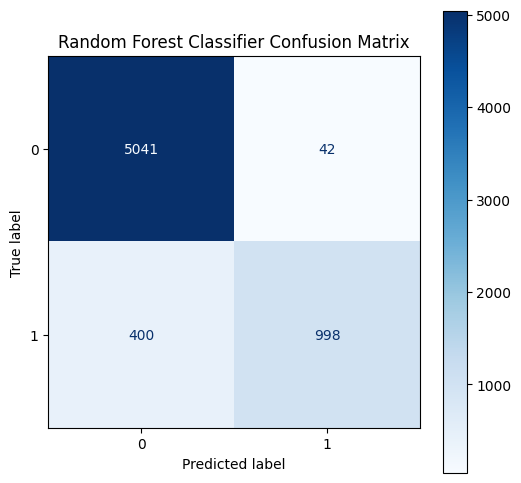

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix for Random Forest Classifier
fig, ax = plt.subplots(figsize=(6, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp_rf.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title('Random Forest Classifier Confusion Matrix')
plt.grid(False)
plt.show()

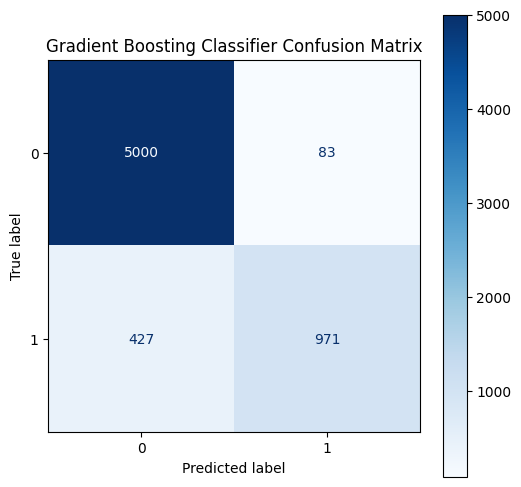

In [47]:
# Confusion Matrix for Gradient Boosting Classifier
fig, ax = plt.subplots(figsize=(6, 6))
cm_gbc = confusion_matrix(y_test, y_pred_gbc, labels=gbc_model.classes_)
disp_gbc = ConfusionMatrixDisplay(confusion_matrix=cm_gbc, display_labels=gbc_model.classes_)
disp_gbc.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title('Gradient Boosting Classifier Confusion Matrix')
plt.grid(False)
plt.show()

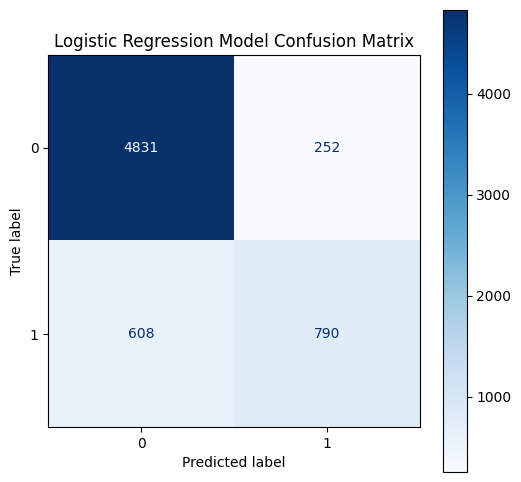

In [48]:
# Confusion Matrix for Logistic Regression Model
fig, ax = plt.subplots(figsize=(6, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=lr_model.classes_)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr_model.classes_)
disp_lr.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title('Logistic Regression Model Confusion Matrix')
plt.grid(False)
plt.show()

## Comparing Model Performance with ROC Curves

The Receiver Operating Characteristic (ROC) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The curve is created by plotting the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings.

*   **True Positive Rate (TPR)**: Also known as Sensitivity or Recall, it is the ratio of correctly predicted positive observations to the all observations in actual class—yes. `TPR = TP / (TP + FN)`
*   **False Positive Rate (FPR)**: It is the ratio of incorrectly predicted positive observations to the all observations in actual class—no. `FPR = FP / (FP + TN)`

### Area Under the Curve (AUC)

The Area Under the ROC Curve (AUC) measures the entire two-dimensional area underneath the entire ROC curve from (0,0) to (1,1). It provides an aggregate measure of performance across all possible classification thresholds.

*   An AUC of 1.0 represents a perfect classifier.
*   An AUC of 0.5 represents a classifier with no discriminatory power (equivalent to random guessing).

Generally, a higher AUC indicates a better performing model.

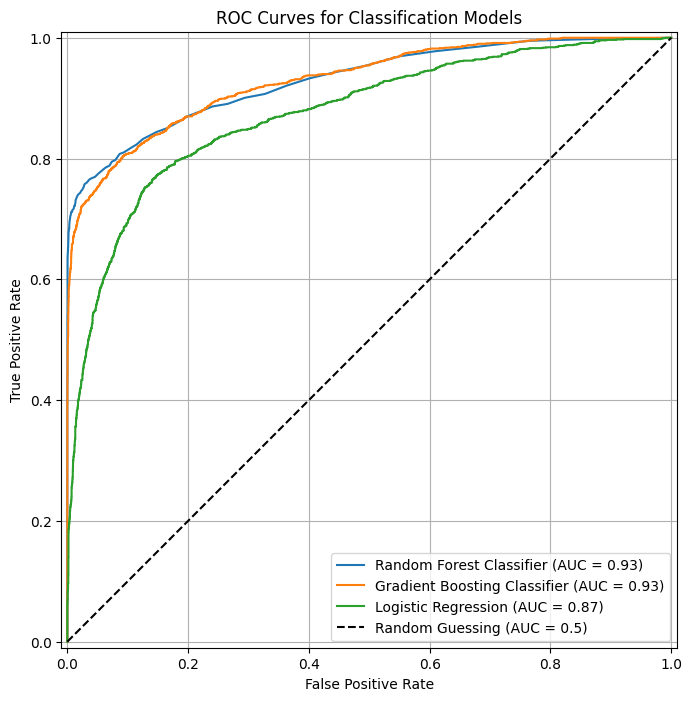

In [49]:
from sklearn.metrics import RocCurveDisplay, roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Random Forest Classifier
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=plt.gca(), name='Random Forest Classifier')

# Gradient Boosting Classifier
RocCurveDisplay.from_estimator(gbc_model, X_test, y_test, ax=plt.gca(), name='Gradient Boosting Classifier')

# Logistic Regression
RocCurveDisplay.from_estimator(lr_model, X_test, y_test, ax=plt.gca(), name='Logistic Regression')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Classification Models')
plt.legend()
plt.grid(True)
plt.show()

**Result** :  Both the Random Forest and Gradient Boosting models demonstrate excellent performance in distinguishing loan defaults, with Random Forest slightly outperforming Gradient Boosting. Logistic Regression, even though still better than random guessing, is  less effective than the ensemble methods.

## Feature Importance Analysis for All Models

Understanding feature importance is crucial for model interpretability, helping us identify which input variables have the most significant impact on the model's predictions. Different models calculate importance differently:

*   **Tree-based models (Random Forest, Gradient Boosting)**: Typically calculate importance based on how much each feature reduces impurity (e.g., Gini impurity) across all trees in the ensemble. Features that are used more often and lead to greater impurity reduction are considered more important.

*   **Linear models (Logistic Regression)**: Feature importance is derived from the absolute value of their coefficients. Larger absolute coefficients indicate a stronger influence on the predicted outcome. The sign of the coefficient indicates the direction of the relationship (positive or negative impact on the probability of default).


--- Random Forest Classifier Feature Importances ---


,Feature,Importance
4,loan_percent_income,0.228157
0,person_income,0.158472
3,loan_int_rate,0.128348
2,loan_amnt,0.083071
8,person_home_ownership_RENT,0.078187
1,person_emp_length,0.068481
16,loan_grade_D,0.058114
5,cb_person_cred_hist_length,0.046901
7,person_home_ownership_OWN,0.018513
11,loan_intent_MEDICAL,0.016465


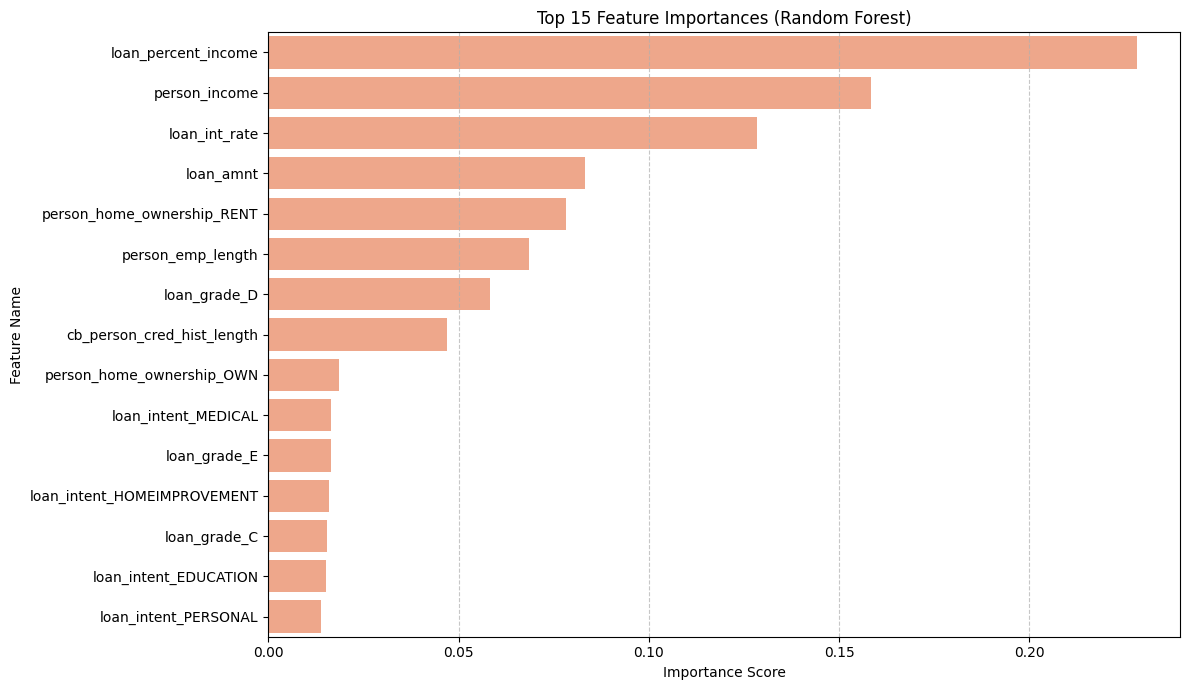

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Random Forest Feature Importance ---
print("\n--- Random Forest Classifier Feature Importances ---")
feature_importances_rf = rf_model.feature_importances_
feature_names = X_train.columns

importance_df_rf = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances_rf
}).sort_values(by='Importance', ascending=False)

display(importance_df_rf.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df_rf.head(15), color='lightsalmon')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


--- Gradient Boosting Classifier Feature Importances ---


,Feature,Importance
4,loan_percent_income,0.316516
8,person_home_ownership_RENT,0.170306
3,loan_int_rate,0.159237
0,person_income,0.131672
16,loan_grade_D,0.085708
1,person_emp_length,0.023939
7,person_home_ownership_OWN,0.021672
15,loan_grade_C,0.019950
17,loan_grade_E,0.012865
11,loan_intent_MEDICAL,0.012068


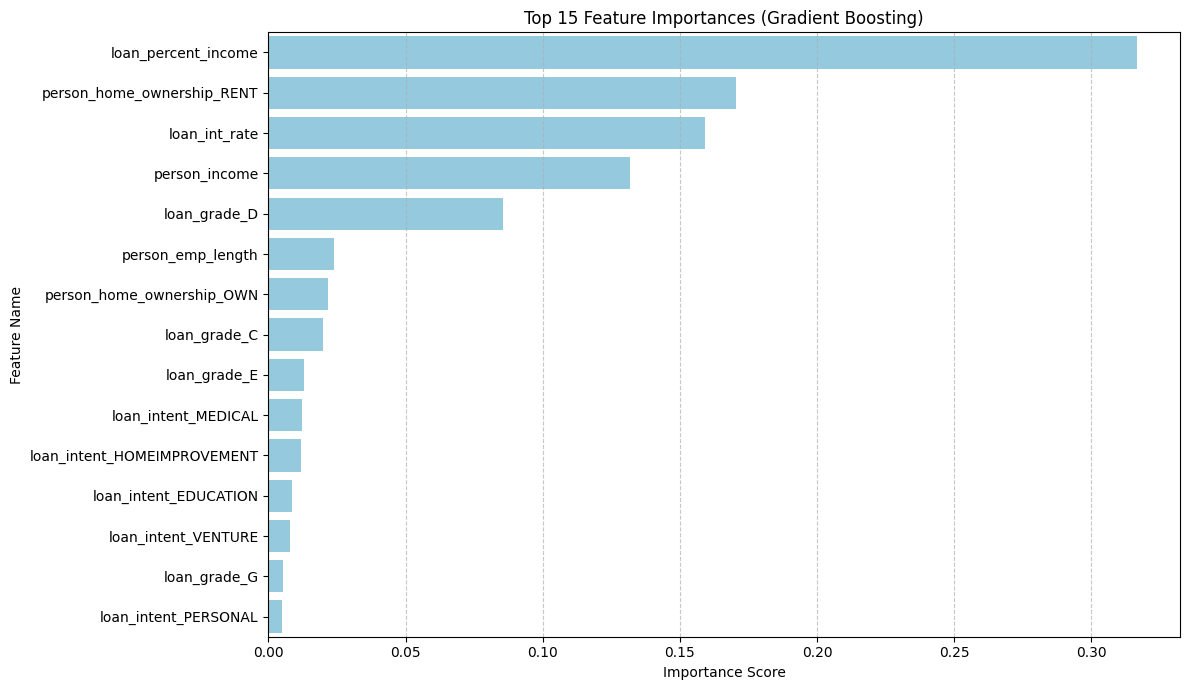

In [56]:
# --- Gradient Boosting Feature Importance ---
print("\n--- Gradient Boosting Classifier Feature Importances ---")
feature_importances_gbc = gbc_model.feature_importances_

importance_df_gbc = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances_gbc
}).sort_values(by='Importance', ascending=False)

display(importance_df_gbc.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df_gbc.head(15),color='skyblue')
plt.title('Top 15 Feature Importances (Gradient Boosting)')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


--- Logistic Regression Feature Importances (Coefficients) ---


,Feature,Coefficient,Abs_Coefficient
19,loan_grade_G,4.415424,4.415424
18,loan_grade_F,2.789003,2.789003
17,loan_grade_E,2.543434,2.543434
16,loan_grade_D,2.328563,2.328563
7,person_home_ownership_OWN,-1.623238,1.623238
4,loan_percent_income,1.418138,1.418138
13,loan_intent_VENTURE,-1.098869,1.098869
9,loan_intent_EDUCATION,-0.865566,0.865566
8,person_home_ownership_RENT,0.823591,0.823591
2,loan_amnt,-0.692988,0.692988


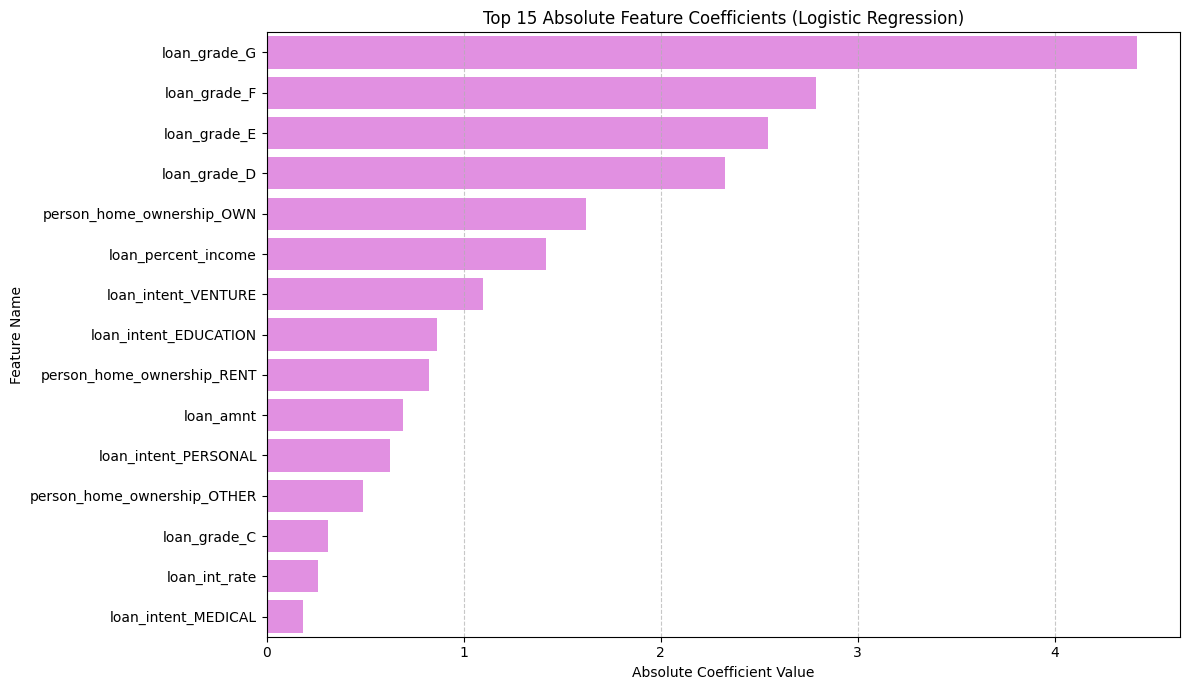

In [59]:
# --- Logistic Regression Feature Importance (Coefficients) ---
print("\n--- Logistic Regression Feature Importances (Coefficients) ---")

# Coefficients are used for feature importance in linear models
coefficients_lr = lr_model.coef_[0]

importance_df_lr = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients_lr,
    'Abs_Coefficient': abs(coefficients_lr)
}).sort_values(by='Abs_Coefficient', ascending=False)

display(importance_df_lr.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='Abs_Coefficient', y='Feature', data=importance_df_lr.head(15),color='violet')
plt.title('Top 15 Absolute Feature Coefficients (Logistic Regression)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Analysis of Feature Importances Across Models

We analyze the feature importances for each model:

### 1. Random Forest Classifier

*   **Key Factors**: "loan_percent_income", "person_income", "loan_int_rate", "loan_amnt", and "person_home_ownership_RENT" consistently appear as the top features. This suggests that the financial burden of the loan relative to income, the borrower's income level, the interest rate, the loan amount itself, and whether the person rents their home are highly influential in predicting loan default.
*   **Relative Importance**: "loan_percent_income" stands out as the single most important feature, reinforcing our earlier EDA findings that a higher percentage of income going towards a loan strongly correlates with default risk.

### 2. Gradient Boosting Classifier

*   **Key Factors**: Similar to Random Forest, "loan_percent_income", "person_income", "loan_int_rate", "loan_amnt", and "person_home_ownership_RENT" are also highlighted as most important. This consistency between two strong ensemble methods strengthens the confidence in these features' predictive power.
*   **Comparison with RF**: While the top features are similar, the exact ranking and magnitude of importance scores might differ slightly, reflecting the different internal mechanisms of Random Forest (bagging) and Gradient Boosting (boosting).

### 3. Logistic Regression

*   **Key Factors(Absolute Coefficients)**: "loan_percent_income", "loan_int_rate", "loan_amnt", "person_home_ownership_RENT", and "loan_grades" are prominent. This indicates that these features have a strong linear relationship with the log-odds of loan default.
*   **(Coefficient Sign)**:
    *   Positive coefficients (e.g., "loan_percent_income", "loan_int_rate", "person_home_ownership_RENT", lower "loan_grade" categories like "loan_grade_D", "loan_grade_E", "loan_grade_F", "loan_grade_G", "cb_person_default_on_file_Y") imply that an increase in these values (or being in that category) increases the likelihood of default.
    *   Negative coefficients (e.g., "person_income", "person_emp_length", higher "loan_grade" categories like "loan_grade_B") imply that an increase in these values (or being in that category) decreases the likelihood of default.
*   **Differences from Tree Models**: While there's overlap, Logistic Regression often assigns importance to individual categories of categorical variables (like specific "loan_grade" categories) more explicitly through its coefficients, whereas tree models might distribute importance more broadly across the original categorical feature.

### Overall Summary

Across all three models, `loan_percent_income`, `person_income`, `loan_int_rate`, `loan_amnt`, and `person_home_ownership_RENT` consistently emerge as the most critical features in predicting loan default. This reinforces the idea that an applicant's financial capacity (income, loan burden) and the terms of the loan itself are paramount. The tree-based models (Random Forest and Gradient Boosting) generally agree on the top features, while Logistic Regression also identifies similar key drivers but quantifies their impact through coefficients, allowing for an understanding of the direction of influence.